In [12]:
import os
from analysis import (
    compute_simulation_statistics,
    run_batch_and_collect_traces,
)

# Configuration Parameters
TARGET_SCORE = 3
NUM_GAMES = 10000
P1_AGENT = "random"
P2_AGENT = "random"

print(
    f"Setup complete. Configured for Target Score = {TARGET_SCORE}, Games ="
    f" {NUM_GAMES:,}"
)

Setup complete. Configured for Target Score = 3, Games = 10,000


In [13]:
print(
    f"Running simulation for {P1_AGENT} vs {P2_AGENT} (Target Score:"
    f" {TARGET_SCORE})..."
)

raw_results, traces = run_batch_and_collect_traces(
    num_games=NUM_GAMES,
    target_score=TARGET_SCORE,
    p1_type=P1_AGENT,
    p2_type=P2_AGENT,
)

print(
    f"Done! Evaluated {len(raw_results):,} games across"
    f" {len(traces)} category traces."
)

Running simulation for random vs random (Target Score: 3)...
  [New Trace Created] Saved: outputs\target_score_3\random_vs_random\traces\single_game_draw_simultaneous_target.csv
  [New Trace Created] Saved: outputs\target_score_3\random_vs_random\traces\single_game_p1_win_score.csv
  [New Trace Created] Saved: outputs\target_score_3\random_vs_random\traces\single_game_p1_win_opponent_stuck.csv
  [New Trace Created] Saved: outputs\target_score_3\random_vs_random\traces\single_game_p2_win_score.csv
  [New Trace Created] Saved: outputs\target_score_3\random_vs_random\traces\single_game_p2_win_opponent_stuck.csv
Done! Evaluated 10,000 games across 5 category traces.


In [14]:
stats = compute_simulation_statistics(raw_results)

print("=" * 60)
print(f"📊 STATISTICAL RESULTS (Target Score = {TARGET_SCORE})")
print("=" * 60)
print(
    f"P1 Win Rate          : {stats['p1_win_rate']*100:.2f}%  (First-Mover"
    " Blue)"
)
print(f"P2 Win Rate          : {stats['p2_win_rate']*100:.2f}%  (Red)")
print(f"Draw Rate            : {stats['draw_rate']*100:.2f}%")
print(
    f"Average Game Length  : {stats['avg_game_length']:.2f} turns (±"
    f"{stats['std_game_length']:.2f})"
)
print(f"Median Game Length   : {stats['median_game_length']} turns")
print(
    f"Min / Max Game Length: {stats['min_game_length']} /"
    f" {stats['max_game_length']} turns"
)
print(
    f"Ending by Score      : {stats['score_game_ratio']*100:.2f}% | Ending by"
    f" Stuck: {stats['stuck_game_ratio']*100:.2f}%"
)
print("-" * 60)
print("Category Breakdown:")
for cat, count in stats["category_counts"].items():
  pct = (count / stats["total_games"]) * 100
  print(f"  - {cat:28s}: {count:5d} ({pct:6.2f}%)")
print("=" * 60)

📊 STATISTICAL RESULTS (Target Score = 3)
P1 Win Rate          : 46.96%  (First-Mover Blue)
P2 Win Rate          : 47.68%  (Red)
Draw Rate            : 5.36%
Average Game Length  : 25.15 turns (±10.56)
Median Game Length   : 25.0 turns
Min / Max Game Length: 4 / 75 turns
Ending by Score      : 82.85% | Ending by Stuck: 11.79%
------------------------------------------------------------
Category Breakdown:
  - draw_simultaneous_target    :   536 (  5.36%)
  - p1_win_score                :  4115 ( 41.15%)
  - p1_win_opponent_stuck       :   581 (  5.81%)
  - p2_win_score                :  4170 ( 41.70%)
  - p2_win_opponent_stuck       :   598 (  5.98%)


In [15]:
import csv
import json

output_dir = f"outputs/target_score_{TARGET_SCORE}/{P1_AGENT}_vs_{P2_AGENT}"

# 1. Save JSON Metrics
with open(os.path.join(output_dir, "summary_metrics.json"), "w") as f:
  json.dump(stats, f, indent=4)

# 2. Save Category CSV Summary
with open(
    os.path.join(output_dir, "category_distribution.csv"), "w", newline=""
) as f:
  writer = csv.writer(f)
  writer.writerow(["category", "count", "percentage"])
  for cat, count in stats["category_counts"].items():
    writer.writerow([cat, count, (count / NUM_GAMES) * 100])

print(f"📂 Successfully exported clean results to: {output_dir}")

📂 Successfully exported clean results to: outputs/target_score_3/random_vs_random


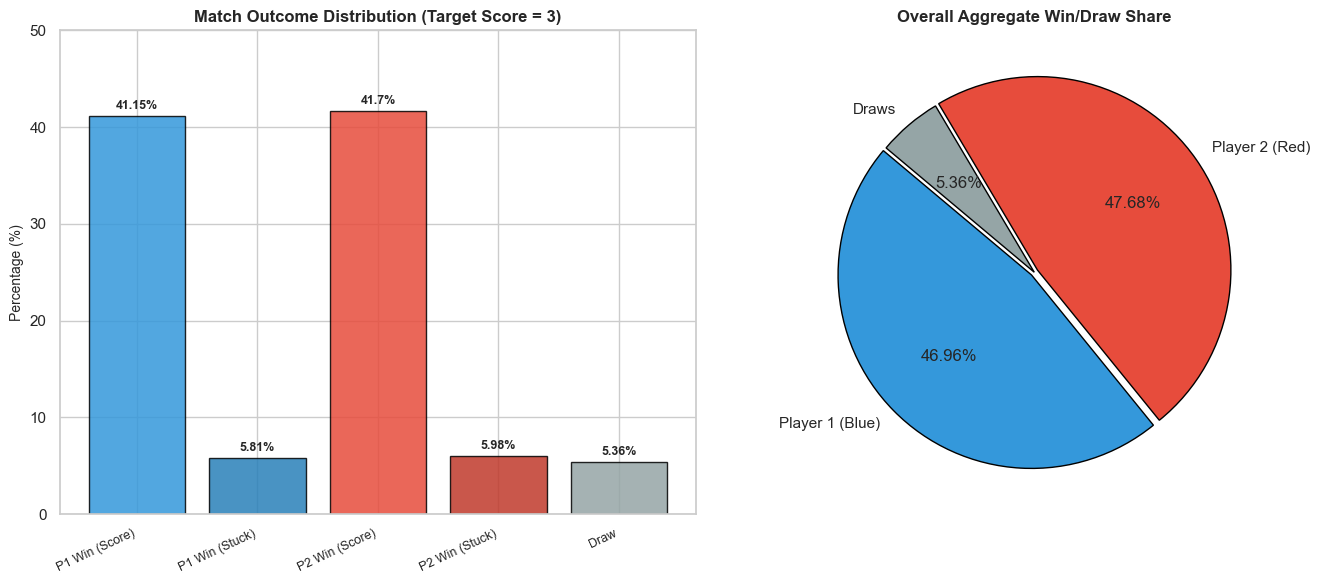

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Data Extraction from Statistical Results
categories = [
    "P1 Win (Score)",
    "P1 Win (Stuck)",
    "P2 Win (Score)",
    "P2 Win (Stuck)",
    "Draw",
]
percentages = [41.15, 5.81, 41.70, 5.98, 5.36]
colors = ["#3498db", "#2980b9", "#e74c3c", "#c0392b", "#95a5a6"]

# Create Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Outcome Breakdown Bar Chart
bars = ax1.bar(
    categories, percentages, color=colors, edgecolor="black", alpha=0.85
)
ax1.set_title(
    "Match Outcome Distribution (Target Score = 3)", fontsize=12, fontweight="bold"
)
ax1.set_ylabel("Percentage (%)", fontsize=10)
ax1.set_ylim(0, 50)
plt.setp(
    ax1.get_xticklabels(), rotation=25, ha="right", fontsize=9
)  # type: ignore

# Add value labels on top of bars
for bar in bars:
  height = bar.get_height()
  ax1.annotate(
      f"{height}%",
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=(0, 3),  # 3 points vertical offset
      textcoords="offset points",
      ha="center",
      va="bottom",
      fontsize=9,
      fontweight="bold",
  )

# Chart 2: Win Rate Comparison (P1 vs P2 vs Draw)
aggregate_labels = ["Player 1 (Blue)", "Player 2 (Red)", "Draws"]
aggregate_rates = [46.96, 47.68, 5.36]
agg_colors = ["#3498db", "#e74c3c", "#95a5a6"]

wedges, texts, autotexts = ax2.pie(
    aggregate_rates,
    labels=aggregate_labels,
    autopct="%1.2f%%",
    colors=agg_colors,
    startangle=140,
    explode=(0.02, 0.02, 0),
    wedgeprops={"edgecolor": "black", "linewidth": 1},
)
ax2.set_title(
    "Overall Aggregate Win/Draw Share", fontsize=12, fontweight="bold"
)

plt.tight_layout()
plt.show()

In [6]:
import random
from analysis import compute_simulation_statistics
from entangled_engine import EntangledGameSimulation


def quick_check(num_games=500, target_score=3, p1="random", p2="random"):
  results = []
  for seed in range(1, num_games + 1):
    random.seed(seed)
    sim = EntangledGameSimulation(
        p1_type=p1, p2_type=p2, target_score=target_score
    )
    results.append(sim.run_simulation())
  return compute_simulation_statistics(results), results

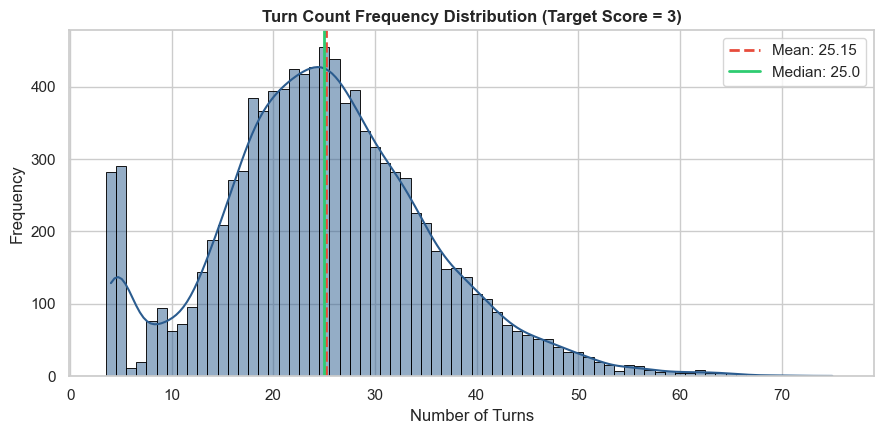

In [17]:
import seaborn as sns

# Set clean modern style
sns.set_theme(style="whitegrid", palette="muted")

# Extract turn counts from raw results
turn_counts = [r["total_moves"] for r in raw_results]
mean_len, median_len = np.mean(turn_counts), np.median(turn_counts)

# Plotting using modern Seaborn (compact, single-line commands)
plt.figure(figsize=(9, 4.5))
ax = sns.histplot(
    turn_counts, discrete=True, kde=True, color="#2b5c8f", edgecolor="black"
)
plt.axvline(
    mean_len,
    color="#e74c3c",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_len:.2f}",
)
plt.axvline(
    median_len,
    color="#2ecc71",
    linestyle="-",
    linewidth=2,
    label=f"Median: {median_len:.1f}",
)
plt.title(
    "Turn Count Frequency Distribution (Target Score = 3)", fontweight="bold"
)
plt.xlabel("Number of Turns")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## Greedy vs Random

🚀 Running Greedy (P1) vs Random (P2) Batch Analysis...
  [New Trace Created] Saved: outputs\target_score_3\greedy_vs_random\traces\single_game_draw_simultaneous_target.csv
  [New Trace Created] Saved: outputs\target_score_3\greedy_vs_random\traces\single_game_p1_win_score.csv
  [New Trace Created] Saved: outputs\target_score_3\greedy_vs_random\traces\single_game_p1_win_opponent_stuck.csv
  [New Trace Created] Saved: outputs\target_score_3\greedy_vs_random\traces\single_game_p2_win_score.csv
  [New Trace Created] Saved: outputs\target_score_3\greedy_vs_random\traces\single_game_p2_win_opponent_stuck.csv


C:\Users\pesal\AppData\Local\Temp\ipykernel_24692\3903133692.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


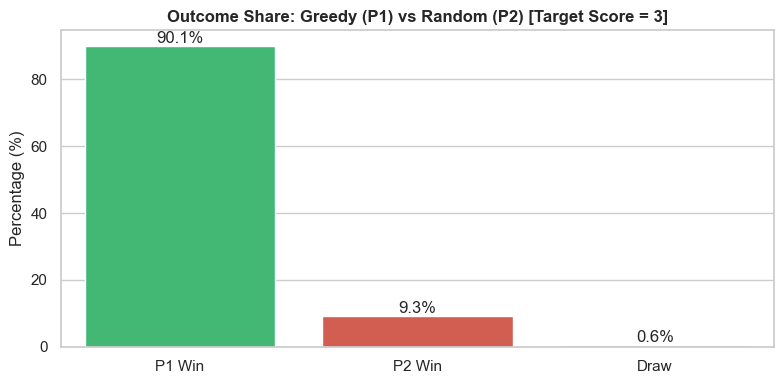

In [18]:
from analysis import (compute_simulation_statistics, run_batch_and_collect_traces)
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

# 1. Execute batch for Greedy (P1) vs Random (P2)
print("🚀 Running Greedy (P1) vs Random (P2) Batch Analysis...")
raw_results_g_v_r, _ = run_batch_and_collect_traces(
    num_games=1000,
    target_score=3,
    p1_type="greedy",
    p2_type="random",
    force_overwrite=False,  # Enforces safe file creation
)

stats_g_v_r = compute_simulation_statistics(raw_results_g_v_r)

# 2. Compact single-line visualization of outcome comparison
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    x=["P1 Win", "P2 Win", "Draw"],
    y=[
        stats_g_v_r["p1_win_rate"] * 100,
        stats_g_v_r["p2_win_rate"] * 100,
        stats_g_v_r["draw_rate"] * 100,
    ],
    palette=["#2ecc71", "#e74c3c", "#95a5a6"],
    ax=ax,
)
ax.set_title(
    "Outcome Share: Greedy (P1) vs Random (P2) [Target Score = 3]",
    fontweight="bold",
)
ax.set_ylabel("Percentage (%)")
for p in ax.patches:
  ax.annotate(
      f"{p.get_height():.1f}%",
      (p.get_x() + p.get_width() / 2.0, p.get_height()),
      ha="center",
      va="bottom",
  )
plt.tight_layout()
plt.show()